In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import thermoift.FeosPlugin as TC
import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps
import numpy as np, matplotlib.pyplot as plt

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=9fdf7dc55066ee5b9f18db89bec84370b746ffb4212bd96e56b9b9cd091d2a38
  Stored in directory: /tmp/pip-ephem-wheel-cache-6plpkwpo/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [3]:
model   = SEC.semi_emperical_correlations()
name    = "carbon dioxide"
T_vals  = np.linspace(220, 300, 30)

T_list, gamma_list, rhoL_list, rhoV_list, Psat_list = [], [], [], [], []

for T_K in T_vals:
    gamma0, rhoL0, rhoV0, Tc, Pc, Psat = model._pure_component_cDFT(name, T_K)

    if np.isnan(gamma0):
        continue

    T_list.append(T_K)
    gamma_list.append(gamma0)
    rhoL_list.append(rhoL0)
    rhoV_list.append(rhoV0)
    Psat_list.append(Psat)

print(f"PC-SAFT Tc (CO2) = {Tc:.2f} K")

PC-SAFT Tc (CO2) = 309.15 K


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:177: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.0 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


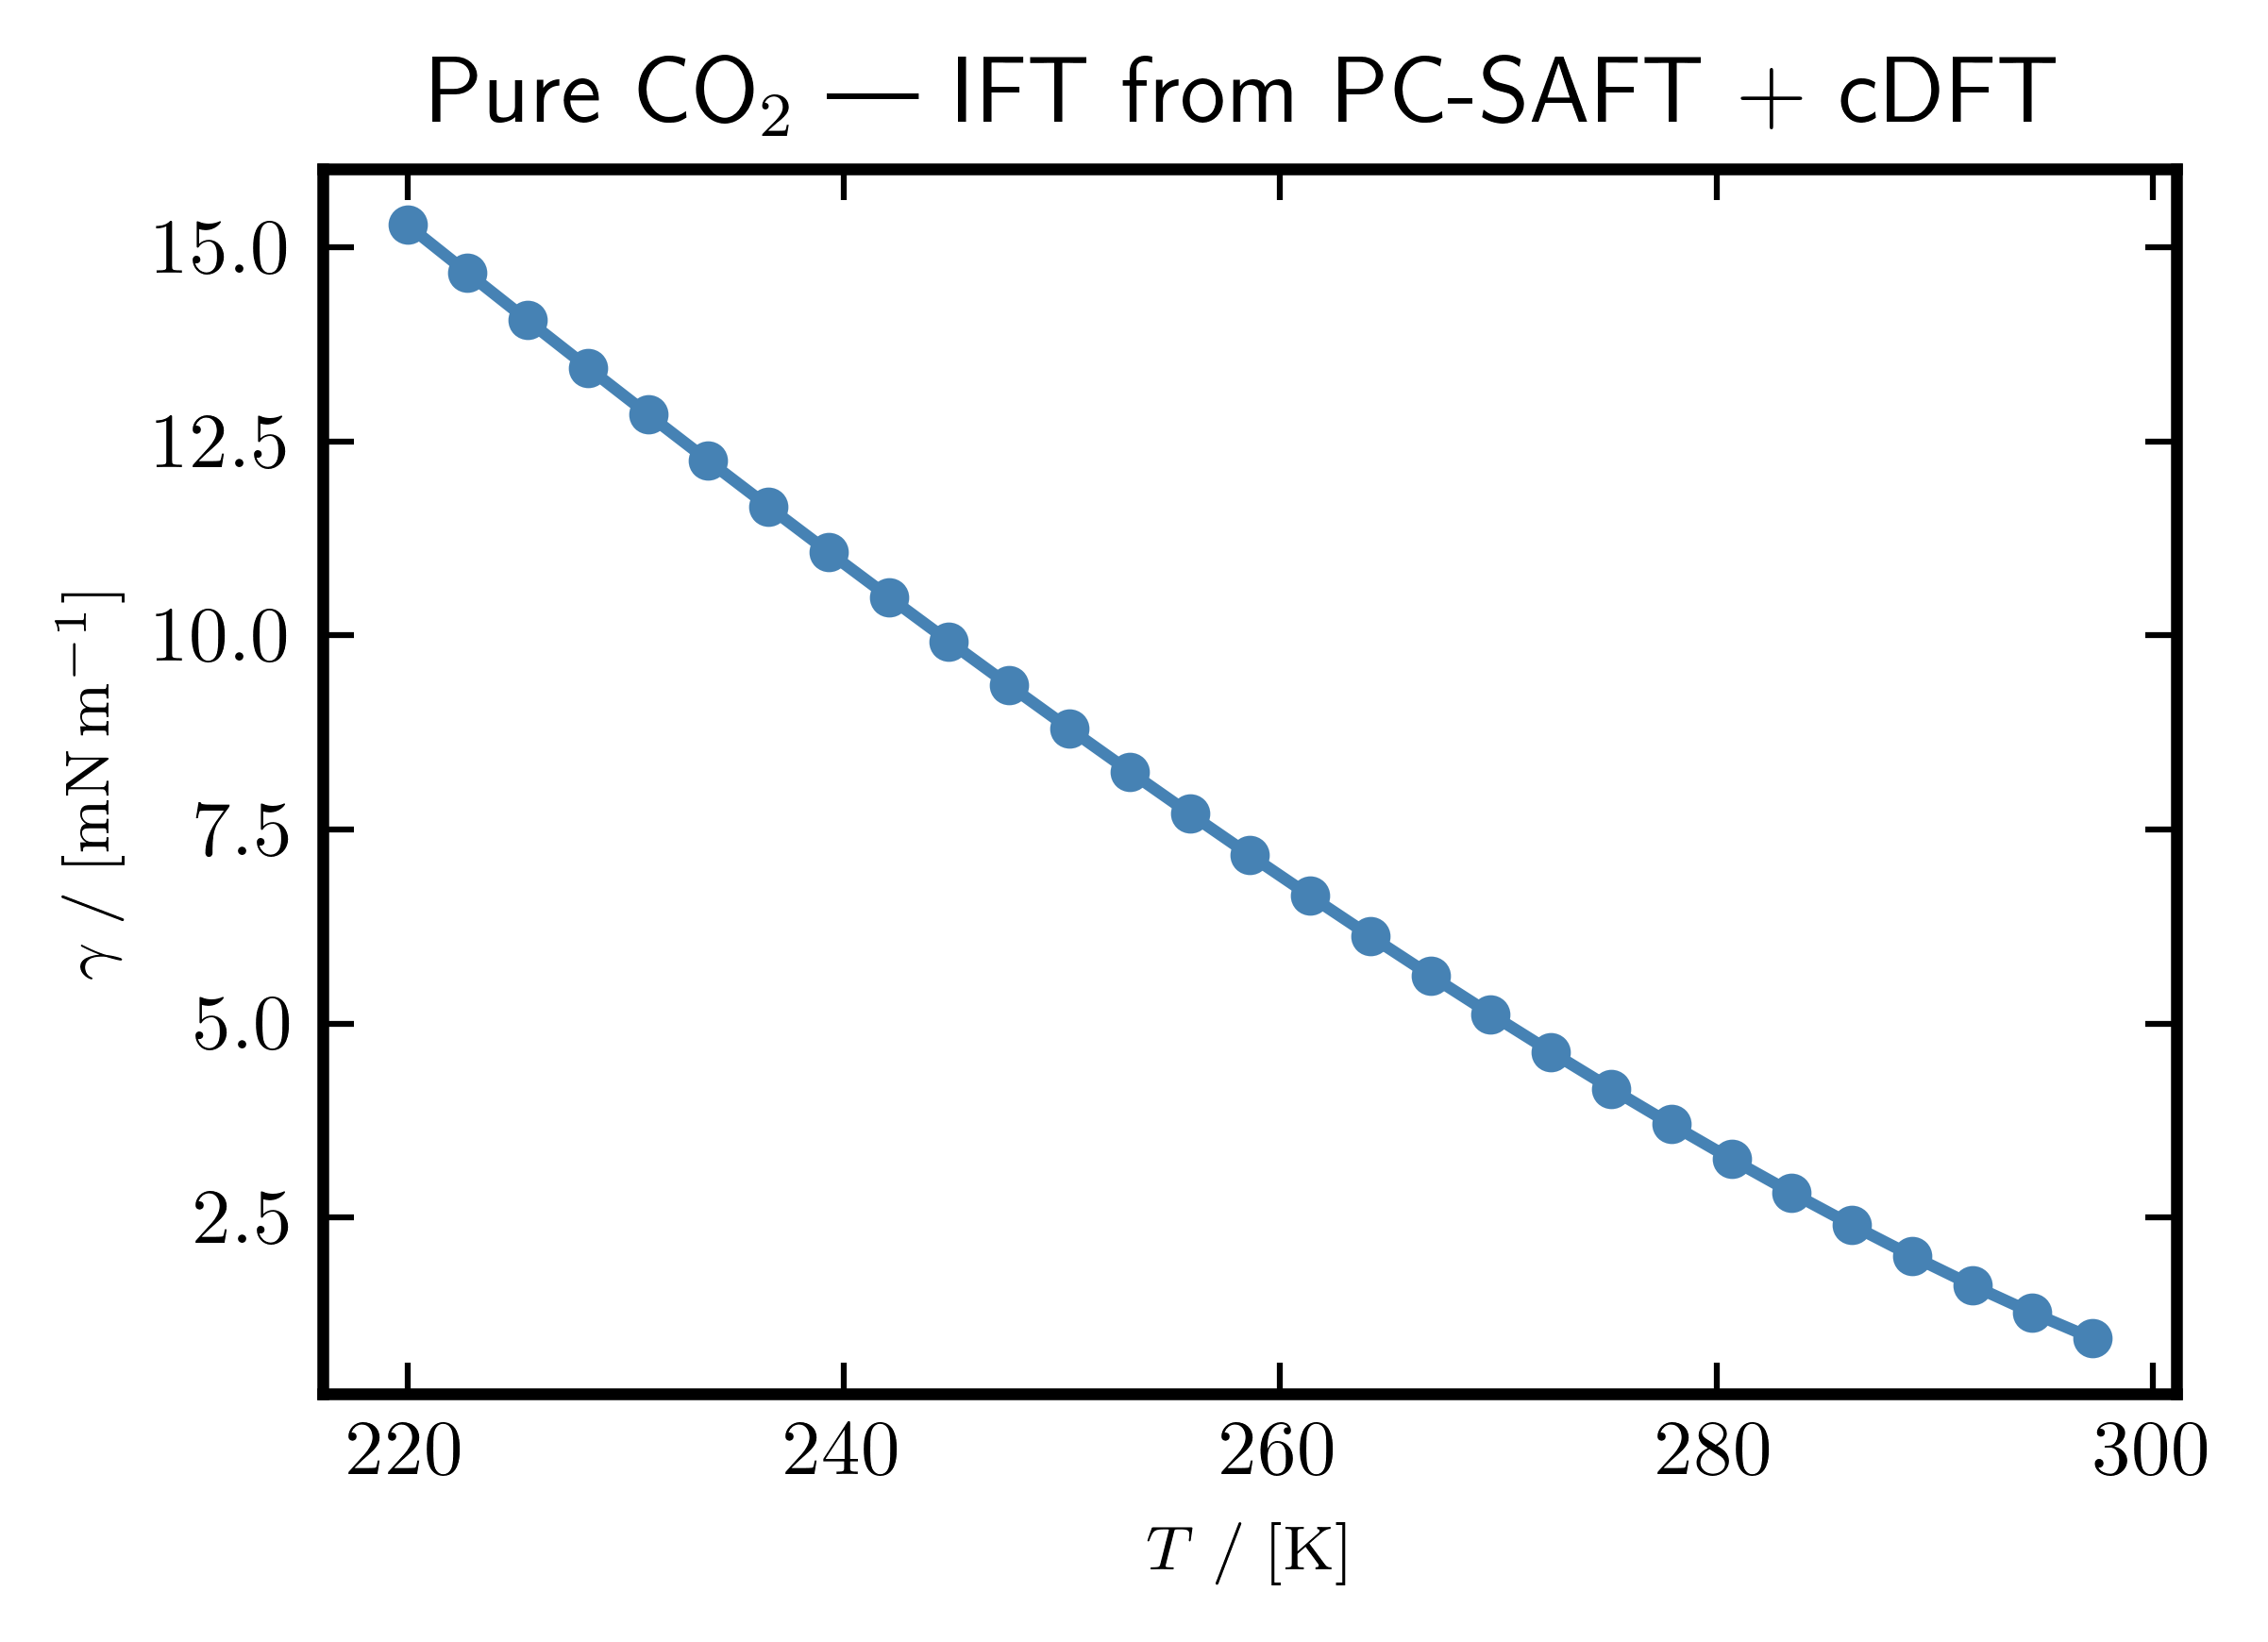

In [4]:
fig, ax = ps.plot_init()
ax.plot(T_list, gamma_list, "o-", markersize=4, color="steelblue")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$")
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$")
ax.set_title(r"Pure CO$_2$ — IFT from PC-SAFT + cDFT")
plt.tight_layout()
plt.show()

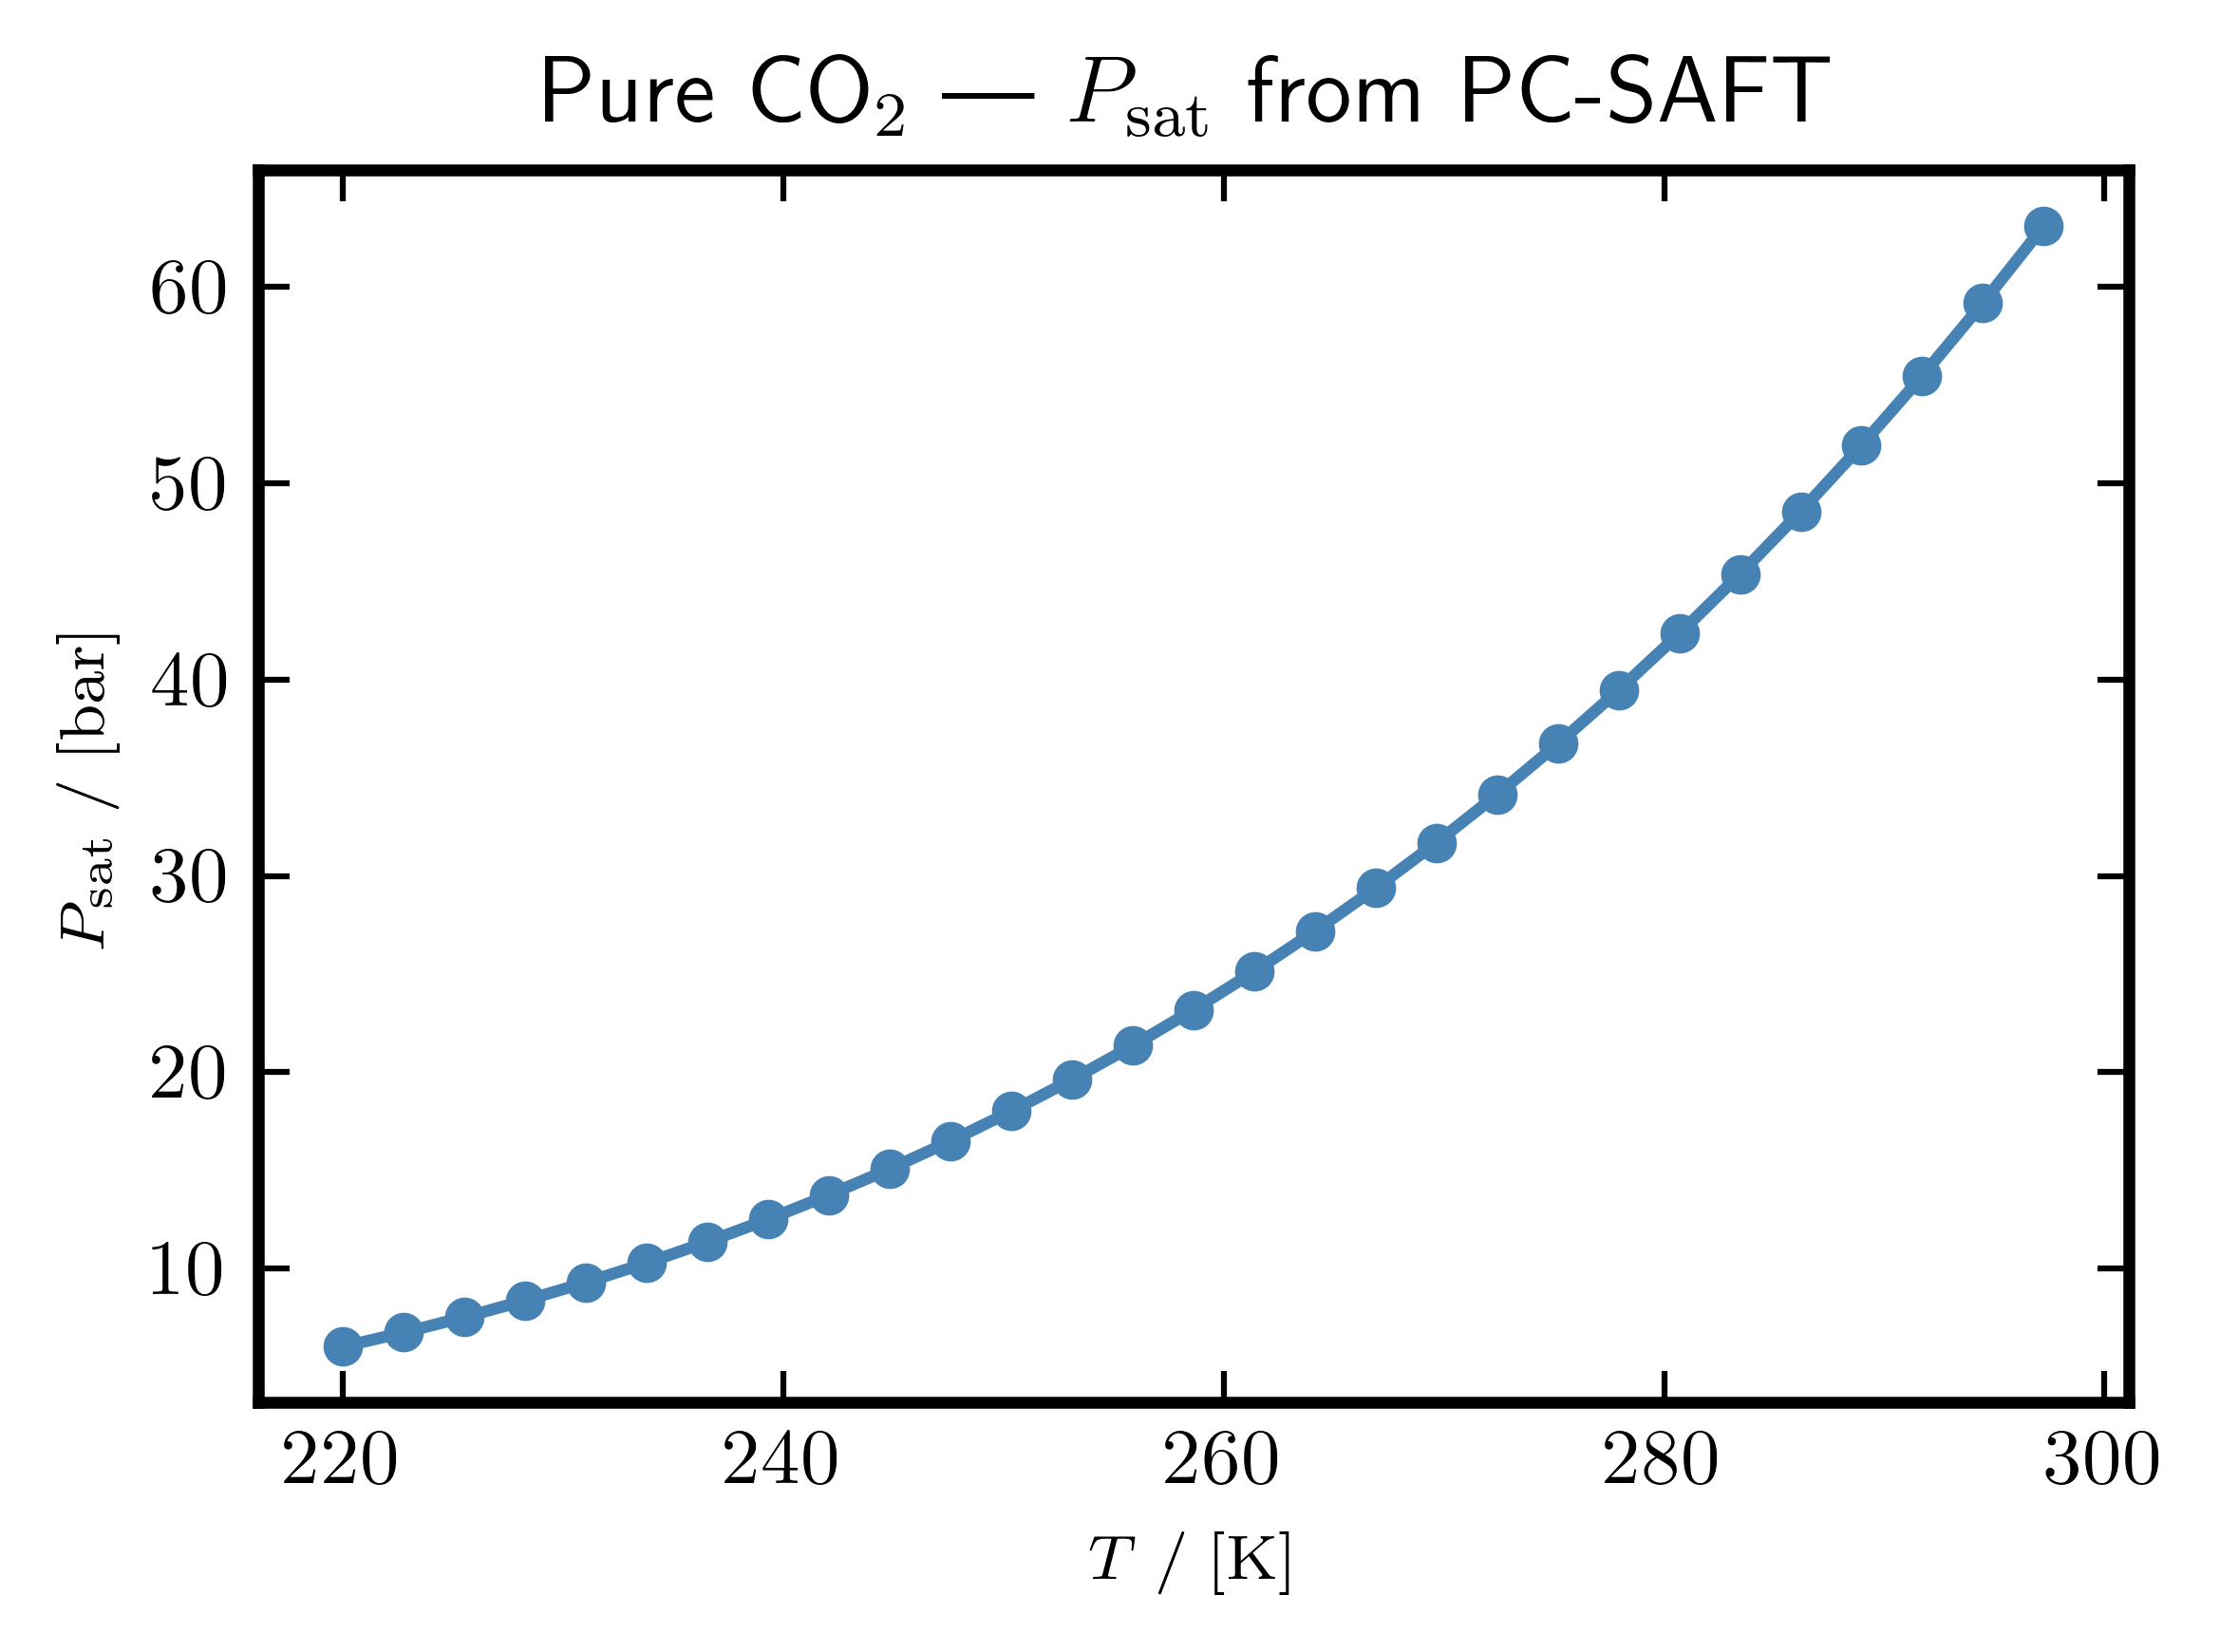

In [5]:
fig, ax = ps.plot_init()
ax.plot(T_list, Psat_list, "o-", markersize=4, color="steelblue")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$")
ax.set_ylabel(r"$P_{\mathrm{sat}} \; / \; [\mathrm{bar}]$")
ax.set_title(r"Pure CO$_2$ — $P_{\mathrm{sat}}$ from PC-SAFT")
plt.tight_layout()
plt.show()